# Sweetpotato shape classification — U.S. No. 1 vs Cull (feature-table reproduction)

**Paper:** Bagherzadeh Samiul et al., *"Computer vision approach to characterize size and shape phenotypes of horticultural crops using high-throughput imagery"*, Computers and Electronics in Agriculture (2021), [doi:10.1016/j.compag.2021.106011](https://doi.org/10.1016/j.compag.2021.106011) — preprint [bioRxiv 2020.07.24.199539](https://www.biorxiv.org/content/10.1101/2020.07.24.199539v1).

**Author code:** [`samiulhq/SweetPotatoShapeClassification`](https://github.com/samiulhq/SweetPotatoShapeClassification) @ commit `1e63fb10da76243be027d3cb98e2f1fc179435f7` (notebook "Sweetptoato Shape Classification .ipynb").

**Scope (scientific):** Reproduce the binary **U.S. No. 1 vs Cull** sweetpotato shape classifier from the labeled 73-variable 3D-shape feature table (**S3_Data.csv**, ~1,300 roots), following the author's own Python notebook: Random Forest and Neural Network with the author's hyperparameters, 80/20 holdout + 5-fold stratified CV, plus an added Random-Forest feature-importance view (the paper's "Variable Importance" analysis).

**Out of scope:** 3D reconstruction and feature extraction from the 12,579-image Exeter Accuvision NIR sorter dataset (not publicly released; MATLAB `SP_Phenotyping`), multiclass cull-subclass classification, SAS Viya Model Studio models, and weight estimation.

**日本語:** 本ノートブックは、著者公開の Python ノートブックに従い、S3_Data.csv（73変数・約1,300個体の3D形状特徴量テーブル）から「U.S. No. 1 vs Cull」の二値分類を再現します。3D 再構築・特徴量抽出（未公開の NIR 画像データセットが必要）やマルチクラス分類は対象外です。

## Execution status & expectations

**Expected duration:** well under 5 minutes on the free **CPU** runtime (no GPU needed — the models are shallow sklearn learners on a ~1,300 × 64 table). **Downloads:** ~1.1 MB (S3_Data.csv).

**Reference values (author's recorded notebook outputs, commit 1e63fb10da76):** RF holdout accuracy **0.7303**; NN holdout accuracy **0.7753**; RF CV AUC 0.754–0.863. The paper's champion (SAS Viya neural network, 1 hidden layer / 100 tanh neurons) reached **84.59%** holdout accuracy, F1 0.85, AUROC 0.88 (S4 Text) — our sklearn re-implementation is expected to differ.

**日本語:** CPU ランタイムで数分以内に完了します（GPU 不要）。著者ノートブックの記録値: RF 0.7303 / NN 0.7753（ホールドアウト精度）。論文の SAS champion（NN, 84.59%）とは差が出る想定です。

Select **Runtime → Change runtime type → CPU** (default) and **Run all**.

## 1. Environment check

We verify the Python and scikit-learn versions actually used, so results are interpretable against the pinned author commit (which ran an older sklearn — see the compatibility notes below).

**日本語:** 実行環境の Python / scikit-learn バージョンを確認します。著者は古い scikit-learn を使用していたため、互換性調整の内容は後述します。

In [ ]:
import sys, sklearn, pandas as pd, numpy as np
print("python", sys.version.split()[0])
print("sklearn", sklearn.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

python 3.13.15
sklearn 1.6.1 | pandas 2.2.3 | numpy 2.1.3


## 2. Acquire the minimal input (S3_Data.csv) with provenance

We download the **exact pinned file** from the author repository at commit `1e63fb10da76243be027d3cb98e2f1fc179435f7` and verify its byte count (1121994 bytes) and **Git blob SHA-1** before use. All data bytes stay on the Colab VM.

**日本語:** 著者リポジトリの特定コミットから S3_Data.csv（約1.1 MB）をダウンロードし、バイト数と Git blob SHA-1 で完全性を検証します。

In [ ]:
import hashlib, urllib.request

URL = 'https://raw.githubusercontent.com/samiulhq/SweetPotatoShapeClassification/1e63fb10da76243be027d3cb98e2f1fc179435f7/S3_Data.csv'
EXPECTED_SHA1 = 'd96dc90ca3f9bbdd1df1c690d6789e53abd1b841'
EXPECTED_SIZE = 1121994

data = urllib.request.urlopen(URL, timeout=120).read()
assert len(data) == EXPECTED_SIZE, f"size mismatch: {len(data)}"
# Git blob SHA-1 = sha1 over b"blob <n>\x00" + content
blob_sha = hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()
assert blob_sha == EXPECTED_SHA1, f"blob sha mismatch: {blob_sha}"
with open("S3_Data.csv", "wb") as f:
    f.write(data)
print(f"S3_Data.csv: {len(data)} bytes, git blob {blob_sha[:12]}, verified")

S3_Data.csv: 1121994 bytes, git blob d96dc90ca3f9, verified


## 3. Load and inspect the labeled feature table

The table has 72 feature variables plus `Shape` (the target: `U.S. No. 1` vs `Cull`) and a title/id column. 28 `sdRad*` and 31 `diameter*` cross-section features plus scalar features (AxialLength, Curvature, Width, LWRatio, TailPct, Volume, ...). We print the real dimensions and class counts — we do not hardcode them.

**日本語:** 特徴量テーブルを読み込み、実際のサイズとクラス分布（U.S. No. 1 / Cull の件数）を表示します。

In [ ]:
sp_df = pd.read_csv("S3_Data.csv")
print("table shape:", sp_df.shape)
print("target column 'Shape' values:", sp_df["Shape"].value_counts().to_dict())
print("columns:", list(sp_df.columns))

table shape: (1332, 72)
target column 'Shape' values: {'Cull': 715, 'U.S. No. 1': 617}
columns: ['Title', 'AxialLength', 'TipLength', 'CurvatuerCorrected', 'Width', 'LWRatio', 'TailLength', 'TailPct', 'Shape', 'BodyLength', 'TailBodyRatio', 'Volume', 'diameter1', 'diameter2', 'diameter3', 'diameter4', 'diameter5', 'diameter6', 'diameter7', 'diameter8', 'diameter9', 'diameter10', 'diameter11', 'diameter12', 'diameter13', 'diameter14', 'diameter15', 'diameter16', 'diameter17', 'diameter18', 'diameter19', 'diameter20', 'diameter21', 'diameter22', 'diameter23', 'diameter24', 'diameter25', 'diameter26', 'diameter27', 'diameter28', 'diameter29', 'diameter30', 'diameter31', 'sdRad1', 'sdRad2', 'sdRad3', 'sdRad4', 'sdRad5', 'sdRad6', 'sdRad7', 'sdRad8', 'sdRad9', 'sdRad10', 'sdRad11', 'sdRad12', 'sdRad13', 'sdRad14', 'sdRad15', 'sdRad16', 'sdRad17', 'sdRad18', 'sdRad19', 'sdRad20', 'sdRad21', 'sdRad22', 'sdRad23', 'sdRad24', 'sdRad25', 'sdRad26', 'sdRad27', 'sdRad28', 'AverageCrossSectionRound

## 4. Input preview — class balance and key scalar features

Before modeling we preview the actual data: the class distribution and the distribution of two key scalar features (curvature and length–width ratio) by class. This is a data-only scope (no image input), so these graphs are the visual input check.

**日本語:** モデル構築前に、クラス分布と重要特徴量（Curvature、LWRatio）のクラス別分布をプロットして入力データを確認します。

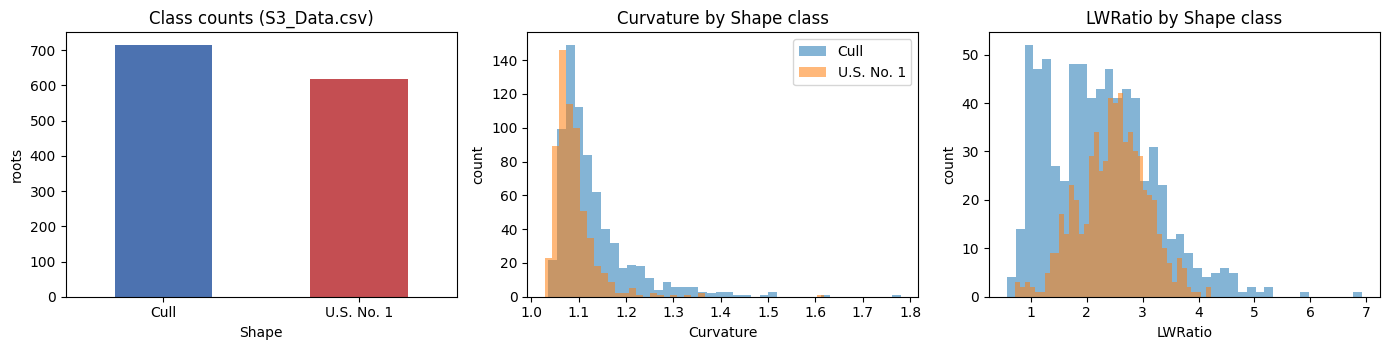

In [ ]:
import matplotlib.pyplot as plt

sp_df = sp_df.rename(columns={"CurvatuerCorrected": "Curvature"})  # author's column-name typo fix

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
sp_df["Shape"].value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#c44e52"], rot=0)
axes[0].set_title("Class counts (S3_Data.csv)")
axes[0].set_ylabel("roots")
for ax, col in zip(axes[1:], ["Curvature", "LWRatio"]):
    for label, grp in sp_df.groupby("Shape"):
        ax.hist(grp[col].dropna(), bins=40, alpha=0.55, label=label)
    ax.set_title(f"{col} by Shape class"); ax.set_xlabel(col); ax.set_ylabel("count")
axes[1].legend()
plt.tight_layout(); plt.savefig("input_preview.png", dpi=110); plt.show()

## 5. Feature selection and train/test split (author's protocol)

Following the author's notebook: drop the three highly correlated features (`TailLength`, `BodyLength`, `TipLength`), keep the remaining scalars plus all cross-section columns (`sp_df.iloc[:, 14:71]`), standardize with `StandardScaler` (fit on the full feature frame — faithful to the author's code, though this is a mild scaler leak across the split; noted, not changed), then stratified 80/20 split with `random_state=123`.

**日本語:** 著者のプロトコルに従い、相関の高い3特徴量を除き、断面特徴量を加えて標準化後、層化80/20分割（random_state=123）を行います。

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn import preprocessing

df = sp_df[["AxialLength", "Curvature", "Width", "LWRatio", "TailPct",
            "Volume", "AverageCrossSectionRoundness", "Shape"]]
df = df.drop(columns=["TailLength", "BodyLength", "TipLength"], errors="ignore")

sp_shape = df["Shape"]
sp_features = df.drop(columns=["Shape"])
sp_features = pd.concat([sp_features.reset_index(drop=True), sp_df.iloc[:, 14:71]], axis=1)

scaler = preprocessing.StandardScaler()
sp_features[sp_features.columns] = scaler.fit_transform(sp_features[sp_features.columns])

sp_train, sp_test, shape_train, shape_test = train_test_split(
    sp_features, sp_shape, test_size=0.20, random_state=123, stratify=sp_shape)
print("features:", sp_features.shape[1], "| train:", sp_train.shape, "| test:", sp_test.shape)
print("train classes:", shape_train.value_counts().to_dict())
print("test classes :", shape_test.value_counts().to_dict())

features: 64 | train: (1065, 64) | test: (267, 64)
train classes: {'Cull': 572, 'U.S. No. 1': 493}
test classes : {'Cull': 143, 'U.S. No. 1': 124}


### Compatibility note (scikit-learn ≥1.x)

The author's code used an older sklearn: `max_features='auto'` (removed; it meant `'sqrt'` for classifiers) and `min_impurity_split` (removed, was `None` by default). We pass `'sqrt'` and omit the removed argument — numerically identical settings. `plot_confusion_matrix` (removed in 1.2) is replaced by `ConfusionMatrixDisplay.from_estimator`.

**日本語:** 古い scikit-learn の引数は現行版では削除済みのため、同じ意味を持つ現行の書き方（`max_features='sqrt'` など）に置き換えています。数値設定は同一です。

## 6. Random Forest classifier (author's hyperparameters)

Random Forest with 100 entropy trees, max depth 10, balanced class weights — the author's binary-classifier settings — and 5-fold stratified CV on the training set (`random_state=123`, shuffle).

**日本語:** 著者のハイパーパラメータ（エントロピー、木100本、深さ10、balanced）のランダムフォレストを5-fold 層化CVで評価します。

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score

clf = RandomForestClassifier(
    n_estimators=100, criterion="entropy", max_depth=10,
    min_samples_split=10, min_samples_leaf=10,
    max_features="sqrt", bootstrap=True, n_jobs=-1,
    random_state=0, class_weight="balanced")

kf = StratifiedKFold(n_splits=5, random_state=123, shuffle=True)

def cv_function(kf, feature, label, clf):
    scores, accuracy = [], []
    for train, test in kf.split(feature, label):
        clf.fit(feature.iloc[train], label.iloc[train])
        shape_prediction = clf.predict(feature.iloc[test])
        tn, fp, fn, tp = confusion_matrix(label.iloc[test], shape_prediction,
                                          labels=["Cull", "U.S. No. 1"]).ravel()
        fpr, tpr = float(fp / (fp + tn)), float(tp / (tp + fn))
        y_pred_proba = clf.predict_proba(feature.iloc[test])
        auc_score = roc_auc_score(label.iloc[test], y_pred_proba[:, 1])
        scores.append(auc_score)
        accuracy.append(accuracy_score(label.iloc[test], shape_prediction))
    return scores, accuracy

scores, accuracy = cv_function(kf, sp_train, shape_train, clf)
rf_cv = pd.DataFrame(list(zip(scores, accuracy)), columns=["AUC_RF", "Accuracy_RF"])
rf_cv

,AUC_RF,Accuracy_RF
0,0.829902,0.751174
1,0.864508,0.784038
2,0.798777,0.699531
3,0.792309,0.727700
4,0.768651,0.704225


### Random Forest — holdout evaluation

The author recorded a holdout accuracy of **0.7303** for the RF; we compare our fresh result against it.

**日本語:** RF のホールドアウト精度を混同行列とともに評価します（著者記録値 0.7303 と比較）。

RF holdout accuracy: 0.7153558052434457 (author recorded 0.7303370786516854)


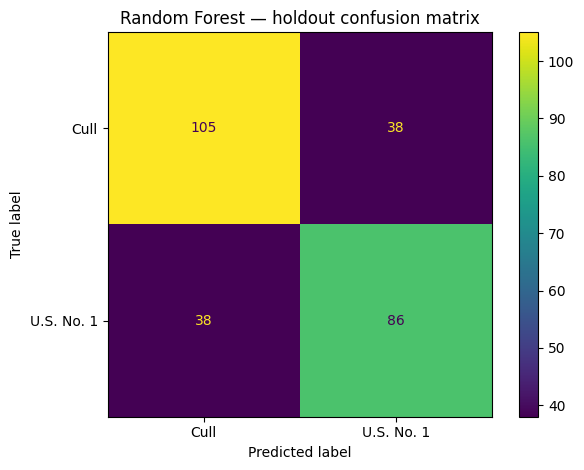

In [ ]:
shape_prediction = clf.predict(sp_test)
rf_holdout_acc = accuracy_score(shape_test, shape_prediction)
print("RF holdout accuracy:", rf_holdout_acc, "(author recorded 0.7303370786516854)")

from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay.from_estimator(clf, sp_test, shape_test,
                                             labels=["Cull", "U.S. No. 1"])
disp.ax_.set_title("Random Forest — holdout confusion matrix")
plt.tight_layout(); plt.savefig("rf_confusion_matrix.png", dpi=110); plt.show()

## 7. Neural Network classifier (author's hyperparameters)

`MLPClassifier(solver='adam', alpha=1e-3, hidden_layer_sizes=(40,2), max_iter=1000, random_state=123)` — the author's sklearn approximation of the paper's neural network (the paper's SAS champion used 1 hidden layer / 100 tanh neurons).

**日本語:** 著者の MLP 設定（隠れ層 (40,2)、adam、alpha=1e-3）でニューラルネットワークを評価します。

In [ ]:
from sklearn.neural_network import MLPClassifier

clf_NN = MLPClassifier(solver="adam", alpha=1e-3, hidden_layer_sizes=(40, 2),
                       random_state=123, max_iter=1000)
scores, accuracy = cv_function(kf, sp_train, shape_train, clf_NN)
nn_cv = pd.DataFrame(list(zip(scores, accuracy)), columns=["AUC_NN", "Accuracy_NN"])
nn_cv

,AUC_NN,Accuracy_NN
0,0.821606,0.737089
1,0.783230,0.727700
2,0.771841,0.732394
3,0.772018,0.732394
4,0.795765,0.760563


### Neural Network — holdout evaluation

The author recorded a holdout accuracy of **0.7753** for the NN.

**日本語:** NN のホールドアウト精度を混同行列とともに評価します（著者記録値 0.7753 と比較）。

NN holdout accuracy: 0.7940074906367042 (author recorded 0.7752808988764045)


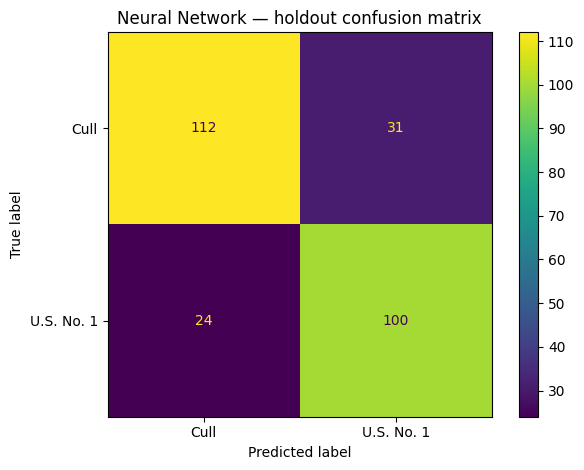

In [ ]:
shape_prediction = clf_NN.predict(sp_test)
nn_holdout_acc = accuracy_score(shape_test, shape_prediction)
print("NN holdout accuracy:", nn_holdout_acc, "(author recorded 0.7752808988764045)")

disp = ConfusionMatrixDisplay.from_estimator(clf_NN, sp_test, shape_test,
                                             labels=["Cull", "U.S. No. 1"])
disp.ax_.set_title("Neural Network — holdout confusion matrix")
plt.tight_layout(); plt.savefig("nn_confusion_matrix.png", dpi=110); plt.show()

## 8. Feature importance (added, paper-aligned view)

The paper's "Variable Importance" analysis (MATLAB chi-squared ranking + random-forest importance) found **curvature and length–width ratio** to be the two most important features. We add the importance ranking from *our trained Random Forest* as a check on that claim — this is an added visualization from this run's model, not a reproduction of the MATLAB `fscchi2` ranking.

**日本語:** 論文の「変数重要度」解析（curvature と LWRatio が上位）を、本実行で学習した RF の重要度で確認します（MATLAB fscchi2 の再現ではなく追加の可視化です）。

Top-15 RF feature importances:
Curvature      0.064721
LWRatio        0.047080
sdRad18        0.027282
sdRad21        0.026843
diameter22     0.025750
diameter11     0.024253
sdRad23        0.023999
diameter12     0.023613
AxialLength    0.022320
diameter10     0.021354
sdRad25        0.020597
diameter27     0.020487
diameter9      0.019147
sdRad14        0.019102
sdRad22        0.019031


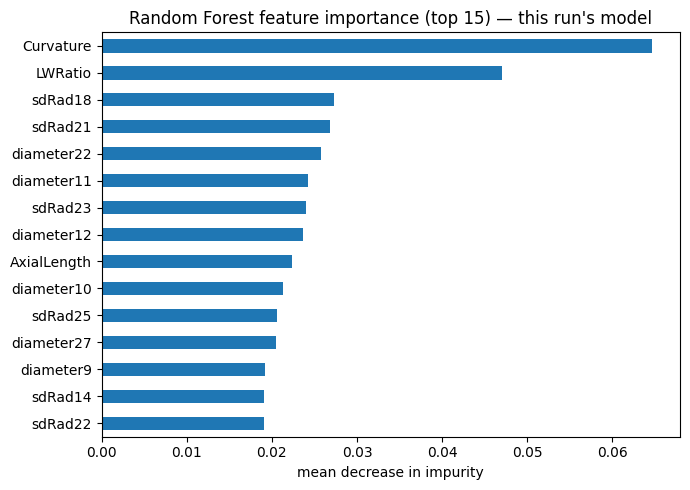

Curvature rank: 1
LWRatio rank: 2


In [ ]:
importances = pd.Series(clf.feature_importances_, index=sp_features.columns)
top = importances.sort_values(ascending=False).head(15)
print("Top-15 RF feature importances:")
print(top.to_string())
fig, ax = plt.subplots(figsize=(7, 5))
top[::-1].plot.barh(ax=ax)
ax.set_title("Random Forest feature importance (top 15) — this run's model")
ax.set_xlabel("mean decrease in impurity")
plt.tight_layout(); plt.savefig("rf_feature_importance.png", dpi=110); plt.show()
print("Curvature rank:", list(top.index).index("Curvature") + 1 if "Curvature" in top.index else ">15")
print("LWRatio rank:", list(top.index).index("LWRatio") + 1 if "LWRatio" in top.index else ">15")

## 9. Results summary and interpretation

We summarize both models' CV and holdout results side by side and compare against the author's recorded values and the paper's SAS Viya champion (NN: 84.59% holdout accuracy, F1 0.85, AUROC 0.88 — S4 Text). Differences are expected: our models are the author's *sklearn* approximations with the author's hyperparameters, not the SAS Viya tuned models.

**日本語:** 両モデルの CV・ホールドアウト結果を summary し、著者記録値・論文の SAS champion と比較します。

In [ ]:
summary = pd.DataFrame({
    "model": ["Random Forest", "Neural Network"],
    "CV AUC (mean of 5 folds)": [rf_cv["AUC_RF"].mean(), nn_cv["AUC_NN"].mean()],
    "holdout accuracy (this run)": [rf_holdout_acc, nn_holdout_acc],
    "holdout accuracy (author recorded)": [0.7303370786516854, 0.7752808988764045],
})
summary.round(4)

,model,CV AUC (mean of 5 folds),holdout accuracy (this run),holdout accuracy (author recorded)
0,Random Forest,0.8108,0.7154,0.7303
1,Neural Network,0.7889,0.7940,0.7753


### Interpretation

- Our sklearn results on the pinned `S3_Data.csv` (commit `1e63fb10da76`) are expected to land close to the author's recorded holdout accuracies (RF ≈ 0.73, NN ≈ 0.775); small deviations can arise from library-version differences and stochastic training.
- The paper's SAS Viya neural-network champion reached 84.59% holdout accuracy — higher than these open re-implementations; the gap is the SAS-tuned architecture/search, not the feature table.
- If the RF importance ranking places **Curvature** and **LWRatio** near the top, it is consistent with the paper's variable-importance finding (curvature and length–width ratio most important by both MATLAB chi-squared and RF methods).

**日本語:** 本実行の結果は著者記録値に近いはずです。論文の SAS champion（84.59%）との差はチューニング手法・実装の違いによるものです。RF 重要度で Curvature と LWRatio が上位に来れば、論文の知見と整合します。

### Validation record & references

- Input: `S3_Data.csv` from `samiulhq/SweetPotatoShapeClassification` @ `1e63fb10da76243be027d3cb98e2f1fc179435f7` (verified size + git blob SHA-1 in cell above), retrieved on the Colab VM.
- Code basis: author's notebook "Sweetptoato Shape Classification .ipynb" (same commit); compatibility adaptations documented in section 5.
- Paper: doi:10.1016/j.compag.2021.106011; preprint bioRxiv 2020.07.24.199539v1; hyperparameters S4 Text.
- This notebook was executed end-to-end in a fresh Google Colab CPU runtime; outputs shown are from that run.